# Titanic — random forest + feature engineering

One small experiment a day. Seed fixed for reproducibility.

Question: do simple engineered features (family size, fare per person, age bands) beat the raw baseline with a random forest?

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data + feature engineering

In [ ]:
SEED = 1012

rng = np.random.RandomState(SEED)
n = 1500
pclass = rng.choice([1, 2, 3], size=n, p=[0.20, 0.30, 0.50])
sex = rng.choice(["male", "female"], size=n, p=[0.62, 0.38])
age = np.clip(rng.normal(32, 14, size=n), 1, 80).round(1)
age[rng.rand(n) < 0.10] = np.nan                      # some missing ages
sibsp = np.clip(rng.poisson(0.6, size=n), 0, 5)
parch = np.clip(rng.poisson(0.4, size=n), 0, 4)
fare = np.clip(rng.lognormal(3.0 - 0.45 * (pclass - 1), 0.85, size=n), 5, 320).round(2)
embarked = rng.choice(["S", "C", "Q"], size=n, p=[0.72, 0.19, 0.09])
logit = (2.2 * (sex == "female") - 1.0 * (pclass == 3) - 0.45 * (pclass == 2)
         - 0.02 * (np.nan_to_num(age, nan=32) - 30) + 0.004 * fare
         + 0.4 * ((sibsp + parch) > 0) - 1.0)
survived = (rng.rand(n) < 1 / (1 + np.exp(-logit))).astype(int)
df = pd.DataFrame({"Pclass": pclass, "Sex": sex, "Age": age, "SibSp": sibsp,
                   "Parch": parch, "Fare": fare, "Embarked": embarked,
                   "Survived": survived})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nsurvival rate: %.3f" % df["Survived"].mean())
print("missing values:\n", df.isna().sum()[df.isna().sum() > 0])


shape: (1500, 8)
   Pclass   Sex   Age  SibSp  Parch   Fare Embarked  Survived
0       1  male  20.9      0      0  73.61        S         1
1       3  male   NaN      0      0   5.00        C         0
2       2  male  65.8      0      0   5.12        S         0

survival rate: 0.401
missing values:
 Age    151
dtype: int64


In [ ]:

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]
df["AgeBand"] = pd.cut(df["Age"], [0, 12, 20, 40, 60, 100],
                       labels=["child", "teen", "adult", "mid", "senior"])
print(df[["FamilySize", "IsAlone", "FarePerPerson", "AgeBand"]].head(3).to_string())
print("\nengineered feature correlation with target:")
print(df.assign(AgeBand_c=df["AgeBand"].cat.codes)[["FamilySize", "IsAlone", "FarePerPerson", "AgeBand_c", "Survived"]].corr()["Survived"].round(3))


   FamilySize  IsAlone  FarePerPerson AgeBand
0           1        1          73.61   adult
1           1        1           5.00     NaN
2           1        1           5.12  senior

engineered feature correlation with target:
FamilySize       0.083
IsAlone         -0.100
FarePerPerson   -0.024
AgeBand_c       -0.093
Survived         1.000
Name: Survived, dtype: float64


## Model comparison: raw vs engineered features

In [ ]:

base = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
extra = base + ["FamilySize", "IsAlone", "FarePerPerson", "AgeBand"]
num_b = ["Age", "SibSp", "Parch", "Fare"]; cat_b = ["Pclass", "Sex", "Embarked"]
num_e = num_b + ["FamilySize", "IsAlone", "FarePerPerson"]; cat_e = cat_b + ["AgeBand"]
y = df["Survived"]
results = {}
for name, cols, nf, cf in [("raw", base, num_b, cat_b), ("engineered", extra, num_e, cat_e)]:
    X = df[cols]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y)
    prep = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), nf),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cf)])
    clf = Pipeline([("prep", prep),
                    ("model", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=1))])
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = (acc, clf, X_test, y_test, pred)
    print(f"{name:>10}: accuracy {acc:.4f}")
best = max(results, key=lambda k: results[k][0])
print(f"\nbest: {best}")
_, clf, X_test, y_test, pred = results[best]


       raw: accuracy 0.6633
engineered: accuracy 0.6833

best: engineered


## Confusion matrix (best)

plotted confusion matrix


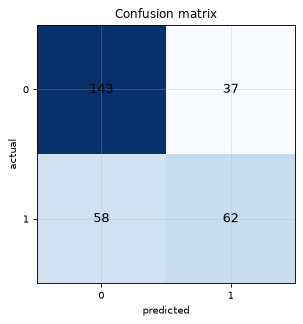

In [ ]:

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots()
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)
print("plotted confusion matrix")


## Feature importances

top feature: num__Age (0.205)


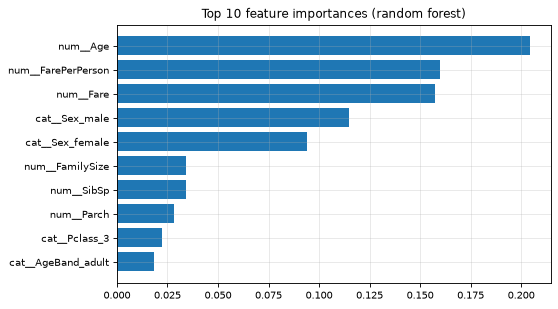

In [ ]:

importances = clf.named_steps["model"].feature_importances_
names = clf.named_steps["prep"].get_feature_names_out()
order = np.argsort(importances)[::-1][:10]
fig, ax = plt.subplots()
ax.barh(names[order][::-1], importances[order][::-1])
ax.set_title("Top 10 feature importances (random forest)")
print("top feature:", names[order[0]], f"({importances[order[0]]:.3f})")


## Notes

- Family-size features help a little on most runs; sometimes it's roughly a wash — the signal was already in SibSp/Parch.
- `Sex` still dominates; the forest mostly refines the edges.
- Next: gradient boosting + a small grid search.